In [13]:
import stlrom
from stlrom import Signal
import matplotlib.pyplot as plt
import numpy as np

def get_time(t0=0, tf=10, dt=0.1):
    return np.arange(t0, tf, dt)

class SignalGen:
    def __init__(self, fun = lambda t:t):
        self.fun =  fun        
        self.interp =  'LINEAR' # 'PREVIOUS' or 'LINEAR'
        self.param_map={}

    def _update_fun():
        pass

    def set_param(self, **kargs):
        for item in kargs:
            self.param_map[item]= kargs[item]
        self._update_fun()

    def get_signal(self, time=None, t0=0, tf=10, dt=.1):
        sig = Signal()
        sig.set_interpol(self.interp)
        if time is None:
            time = get_time(t0, tf, dt)
        for t in time:
            sig.append_sample(t, self.fun(t))
        sig.end_time = tf            
        return sig

class OscillSignalGen(SignalGen):
    def __init__(self, period=1, amplitude=1, base=0, damp=1):        
        super().__init__()
        self.param_map= {'period':1,'amplitude':1, 'base':0, 'damp':0}        
        self._update_fun()        

    def _update_fun(self):
        T = self.param_map['period']
        A = self.param_map['amplitude']
        d = self.param_map['damp']
        base =  self.param_map['base']
        self.fun = lambda t: np.exp(d*t)*A*np.sin(2*np.pi*t/T)+base


class PWCSignalGen(SignalGen):
    def __init__(self, times=[0, 1.], values=[0., 1.]):        
        super().__init__()
        self.param_map= {'times':times,'values':values}        
        self._update_fun()        

    def _update_fun(self):
        s = Signal()
        for t,v in zip(self.param_map['times'], self.param_map['values']):            
            s.append_sample(t,v,0.)
        self.sig = s
        self.fun = lambda t: s.value_at(t)

    def get_signal(self, t0=0, tf=10):        
        s = self.sig
        s.resize(t0, tf)
        return s

step_gen = PWCSignalGen()
osc_gen  = OscillSignalGen()


<Axes: title={'center': 'Signal Plot'}, xlabel='Time', ylabel='Value'>

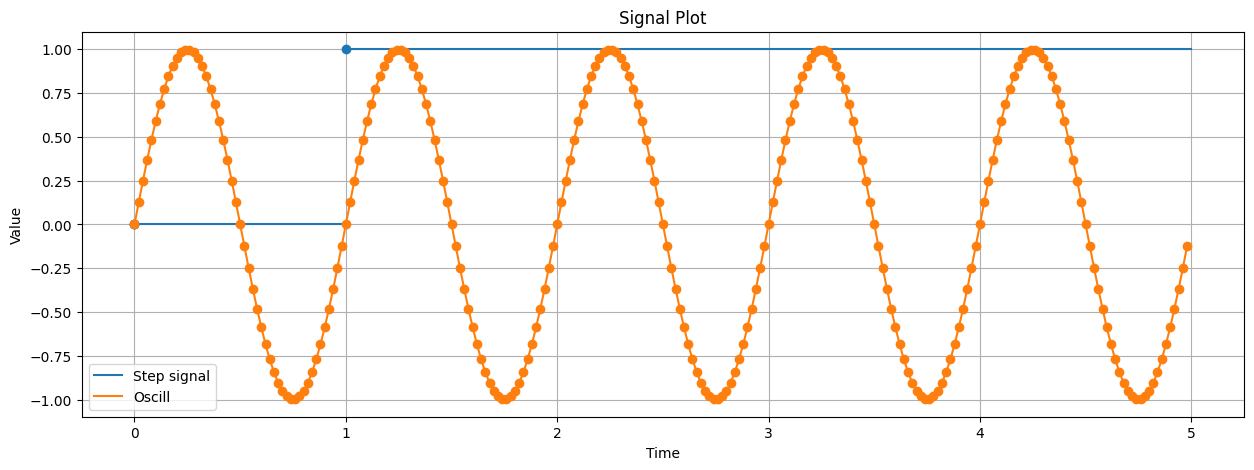

In [14]:
step_sig = step_gen.get_signal(t0=0, tf=5)
ax = step_sig.plot(label= 'Step signal')
sin_sig = osc_gen.get_signal(dt=0.02, tf=5)
sin_sig.plot(ax=ax, label='Oscill')


In [31]:
driver = stlrom.STLDriver()
driver.parse_string('signal step, sin')
driver.parse_string('mu_step := step[t]==0')
driver.parse_string('mu_sin := sin[t]==0')
driver.data = [step_sig, sin_sig]


In [32]:
driver.get_rob('mu_step', 0)

1e-10